In [1]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import glob
import anndata
import sys
from scipy.io import mmread
sys.path.append(r'/media/data2/samba/xjlab/')

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

2024-10-15 13:32:21.506187: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-15 13:32:26.172981: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


scanpy==1.9.3 anndata==0.10.5.post1 umap==0.5.3 numpy==1.24.4 scipy==1.13.1 pandas==2.2.2 scikit-learn==1.3.0 statsmodels==0.14.1 python-igraph==0.10.6 louvain==0.7.1 pynndescent==0.5.6


In [3]:
# results_file = 'write/stargazer.h5ad'  # the file that will store the analysis results

In [3]:
adata = anndata.read_h5ad('/media/data2/samba/ssong/data/Developmental somatosensory/done/P4.h5ad')

In [88]:
genes = ['Arpp21', 'Satb2', 'Gad1', 'Gad2','Mef2c', 'Erbb4', 'Plcxd3', 'Elmo1', 'Igfbp4',  'Nxph1', 'Nxph2', 'Cacng2', 'Sst', 'Htr3a', 'Vip', 'Cxcl14']

/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:169: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(

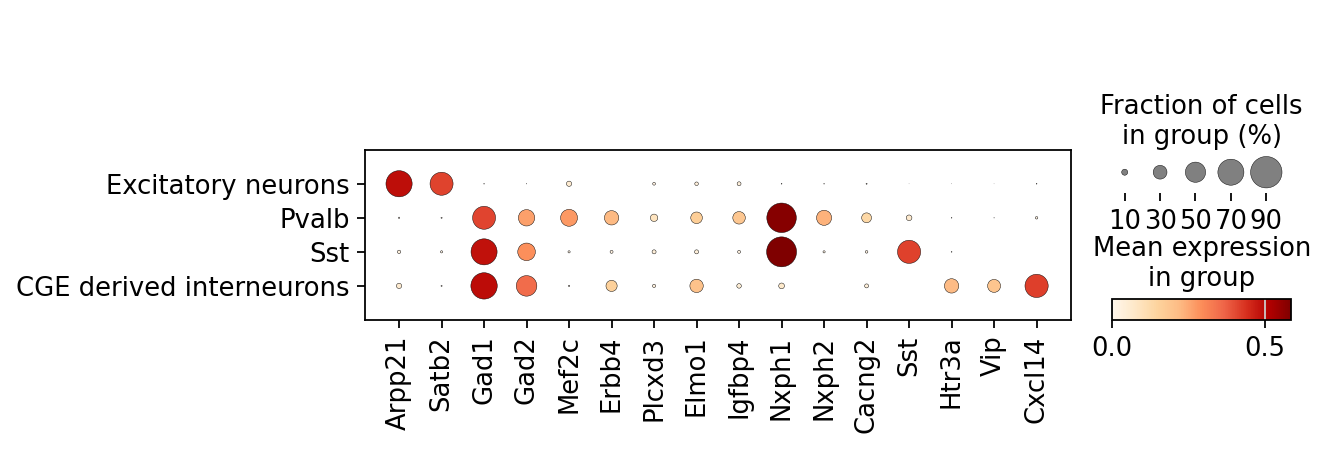

In [103]:
# 假设打印的类别为['CGE derived interneurons', 'Excitatory neurons', 'Pvalb', 'Sst']
cluster_order = ['Excitatory neurons', 'Pvalb', 'Sst', 'CGE derived interneurons']

adata.obs['merged'] = adata.obs['merged'].cat.reorder_categories(cluster_order, ordered=True)

# 使用新的AnnData对象进行点图绘制
sc.pl.dotplot(adata, var_names=genes, groupby='merged', log=True, color_map='OrRd', save='P4.svg')